In [158]:
import pandas as pd
import glob

In [159]:
path = 'data/'

In [160]:
prod_files = glob.glob(f"{path}/*Produktionsplanung.xlsx")
prod_dfs = []

In [161]:
for file in prod_files:
    df = pd.read_excel(file)
    
    # leave only the necessary columns (the names are in German and in all files are the same)
    df_reduced = df[['Prod.Dat.', 'Gebinde', 'Bezeichnung', 'Sollmenge', 'Ausgabe']]
    
    # remame for convenience
    df_reduced.columns = ['date', 'gebinde', 'dish_name', 'target_amount', 'output']
    
    # adding it to the dataframelist
    prod_dfs.append(df_reduced)

In [162]:
prod_df = pd.concat(prod_dfs, ignore_index=True)

In [163]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [164]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.0+ KB


In [165]:
prod_df['date'] = pd.to_datetime(prod_df['date'], format='%d/%m/%Y')

In [166]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [167]:
prod_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16254 entries, 0 to 16253
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           16254 non-null  datetime64[ns]
 1   gebinde        15810 non-null  object        
 2   dish_name      16254 non-null  object        
 3   target_amount  16254 non-null  int64         
 4   output         16254 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 635.0+ KB


In [168]:
prod_df.head(20)

,date,gebinde,dish_name,target_amount,output
0,2014-01-07,Reis,Butterreis,15,15
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190
8,2014-01-07,Pommes frites,Pommes-Frites,200,200
9,2014-01-08,Reis,Butterreis,10,10


In [169]:
# Sollmenge = 0
print(f"Total rows in all Produktionsplanung: {len(prod_df)}")

total_target_zero = (prod_df['target_amount'] == 0).sum()
print(f"Total rows in prod_df with target_amount=0: {total_target_zero}")

print(f'The proportion of such lines: {total_target_zero / len(prod_df):.2%}')

Total rows in all Produktionsplanung: 16254
Total rows in prod_df with target_amount=0: 2930
The proportion of such lines: 18.03%


In [170]:
verkaufs_files = glob.glob('data/*Verkaufszahlen.xlsx')

verkaufs_dfs = []

for file in verkaufs_files:
    df = pd.read_excel(file, header=None)

    # === 1. Read dates ===
    # row 4 (index 3), starting from column I (index 8)
    date_row = df.loc[3, 8:]  

    # Take only non-empty dates
    valid_date_cols = date_row[date_row.notna()]
    
    # Convert to dictionary: {column: date}
    date_map = valid_date_cols.to_dict()

    # === 2. Read dish names ===
    # Column G (index = 6), starting from a certain row (e.g., row 5)
    row_idx = 5 
    while row_idx < len(df):
        dish = df.loc[row_idx, 6] 
        if pd.isna(dish):  
            row_idx += 1
            continue  
        # === 3. Read sales for each date ===
        for col_idx, raw_date in date_map.items():
            sold = df.loc[row_idx, col_idx]
            if pd.notna(sold):
                verkaufs_dfs.append({
                    'dish_name': dish,
                    'date': pd.to_datetime(raw_date, format='%Y.%m.%d', errors='coerce'),
                    'sold_amount': sold
                })
        row_idx += 1  

verkauf_df = pd.DataFrame(verkaufs_dfs)

# Filter out invalid dates (for example, if there was "Gesamt" somewhere)
verkauf_df = verkauf_df[verkauf_df['date'].notna()]
verkauf_df = verkauf_df.sort_values('date').reset_index(drop=True)

print(verkauf_df.head())


                         dish_name       date  sold_amount
0                   Kartoffelsalat 2014-01-07           74
1                             Reis 2014-01-07           15
2                       Kartoffeln 2014-01-07            3
3  Essen- Soziales ohne Berechnung 2014-01-07            1
4                    Pommes frites 2014-01-07          187


In [171]:
verkauf_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   dish_name    13114 non-null  object        
 1   date         13114 non-null  datetime64[ns]
 2   sold_amount  13114 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 307.5+ KB


In [172]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2015-02-12')]

,dish_name,date,sold_amount
1877,Essen 5,2015-02-12,72
1878,Essen 1,2015-02-12,82
1879,Reis,2015-02-12,5
1880,Kartoffelkloss 200g,2015-02-12,8
1881,Pommes frites,2015-02-12,19
1882,Essen- Soziales ohne Berechnung,2015-02-12,1
1883,Nudeln,2015-02-12,8
1884,Essen 4,2015-02-12,33


In [173]:
prod_df[prod_df['date'] == pd.Timestamp('2015-02-12')]

,date,gebinde,dish_name,target_amount,output
2195,2015-02-12,Reis,Butterreis,15,15
2196,2015-02-12,Kloß 200 gr,"Kloß, 200g",8,8
2197,2015-02-12,Nudeln,Nudeln Spirelli,20,20
2198,2015-02-12,NaN,Kräuterbraten v.Schwein m. Kloß u. Rotk,191,191
2199,2015-02-12,Essen 4 Mensen VK,Kartoffel-Broccoli-Flan,40,40
2200,2015-02-12,Essen 5 Mensen VK,Thai- Wraps mit Chilli-Ingwer-Dip- Vegan,76,76
2201,2015-02-12,Pommes frites,Pommes-Frites,19,19


### Preliminary observations

We have collected data from two different sources:

- `prod_df`: contains information from all *Produktionsplanung* (production planning) Excel files, including planned and actual quantities (`Sollmenge`, `Ausgabe`).
- `verkauf_df`: contains sales data extracted from *Verkaufszahlen* files, representing the actual number of dishes sold per day.

Although the `Ausgabe` column in `prod_df` is meant to reflect the actual number of dishes distributed, it **does not always match** the corresponding sales values found in `verkauf_df`. This discrepancy is likely due to differences in data collection or reporting logic between the two sources.

**Conclusion:**  
For the remainder of the analysis, we will **rely on the data from `verkauf_df`** as the ground truth for the number of dishes sold, since it provides a more accurate and consistent daily breakdown of sales.

In [174]:
verkauf_df[verkauf_df['date'] == pd.Timestamp('2020-06-16')]

,dish_name,date,sold_amount
9542,Essen 4,2020-06-16,55
9543,Pizza veget./vegan,2020-06-16,7
9544,Essen 1,2020-06-16,37
9545,Pizza Fleisch/Fisch,2020-06-16,9


In [175]:
prod_df[prod_df['date'] == pd.Timestamp('2020-06-16')]

,date,gebinde,dish_name,target_amount,output
10785,2020-06-16,Essen 1 Mensen VK,Bratwürste - Fränkische Art,37,37
10786,2020-06-16,Essen 4 Mensen VK,Pasta mit Tomaten-Chilipesto und frische,0,55
10787,2020-06-16,Pizza Fleisch/Fisch,EP - Pizza Speziale,25,9
10788,2020-06-16,Kartoffeln,"Kartoffeln, gar",0,0
10789,2020-06-16,Reis,Reis,5,0
10790,2020-06-16,Pizza vegetarisch/vegan,EP - Pizza Margherita,36,7


In [176]:
import re

# Function to extract "Essen X" from a string
def extract_essen(gebinde):
    if isinstance(gebinde, str):
        match = re.match(r'(Essen\s\d)', gebinde)
        if match:
            return match.group(1)  # return only "Essen 1"
    return gebinde  # if not Essen — return as is

# Apply to prod_df
prod_df['gebinde_clean'] = prod_df['gebinde'].apply(extract_essen)

In [177]:
prod_df.head(10)

,date,gebinde,dish_name,target_amount,output,gebinde_clean
0,2014-01-07,Reis,Butterreis,15,15,Reis
1,2014-01-07,Kartoffeln,"Kartoffeln, geschält",3,3,Kartoffeln
2,2014-01-07,Kartoffelsalat,Kartoffelsalat fertig,80,80,Kartoffelsalat
3,2014-01-07,Nudeln,Nudeln Fusilli,0,0,Nudeln
4,2014-01-07,Spätzle,"Spätzle, frisch",0,0,Spätzle
5,2014-01-07,Essen 1 Mensen VK,Hacklett - Hacksteak,162,162,Essen 1
6,2014-01-07,Essen 2 Mensen VK,Puten Cordon Bleu mit Zitrone,240,240,Essen 2
7,2014-01-07,Essen 3 Mensen VK,Pasta mit Tomate-Gemüsesoße,190,190,Essen 3
8,2014-01-07,Pommes frites,Pommes-Frites,200,200,Pommes frites
9,2014-01-08,Reis,Butterreis,10,10,Reis


In [178]:
# Merge by date and "Essen"
verkauf_df_enriched = verkauf_df.merge(
    prod_df[['date', 'gebinde_clean', 'dish_name']],
    left_on=['date', 'dish_name'],
    right_on=['date', 'gebinde_clean'],
    how='left'
)

# Create the final column: use the real dish name if found, otherwise keep the original
verkauf_df_enriched['final_dish_name'] = verkauf_df_enriched['dish_name_y'].combine_first(verkauf_df_enriched['dish_name_x'])

# Remove unnecessary columns
verkauf_df_enriched = verkauf_df_enriched[['date', 'dish_name_x', 'sold_amount', 'final_dish_name']]
verkauf_df_enriched.columns = ['date', 'original_name', 'sold_amount', 'dish_name']


In [179]:
verkauf_df_enriched.head(10)

,date,original_name,sold_amount,dish_name
0,2014-01-07,Kartoffelsalat,74,Kartoffelsalat fertig
1,2014-01-07,Reis,15,Butterreis
2,2014-01-07,Kartoffeln,3,"Kartoffeln, geschält"
3,2014-01-07,Essen- Soziales ohne Berechnung,1,Essen- Soziales ohne Berechnung
4,2014-01-07,Pommes frites,187,Pommes-Frites
5,2014-01-07,Essen 3,185,Pasta mit Tomate-Gemüsesoße
6,2014-01-07,Essen 2,237,Puten Cordon Bleu mit Zitrone
7,2014-01-07,Essen 1,159,Hacklett - Hacksteak
8,2014-01-08,Röstkartoffeln,34,Röstkartoffeln (EH)
9,2014-01-08,Nudeln,1,Nudeln Fusilli


### 1. The most popular dishes
The goal: to find out which dishes were sold most often

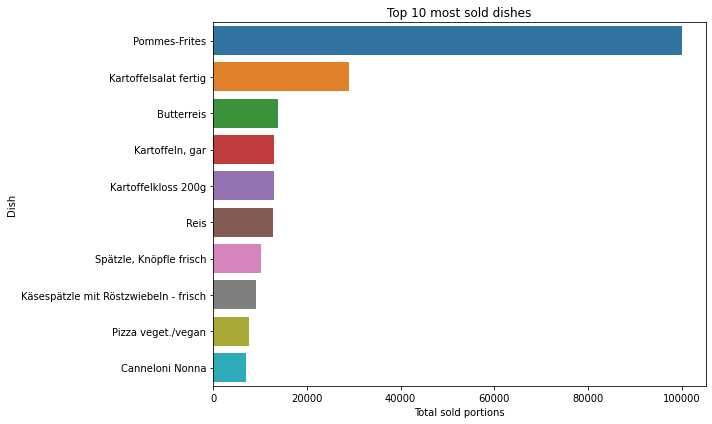

In [180]:
import matplotlib.pyplot as plt
import seaborn as sns

top_dishes = verkauf_df_enriched.groupby('dish_name')['sold_amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_dishes.values, y=top_dishes.index)
plt.title('Top 10 most sold dishes')
plt.xlabel('Total sold portions')
plt.ylabel('Dish')
plt.tight_layout()
plt.show()

### 2. Sales by day of the week
Goal: to understand which days of the week have the most sales

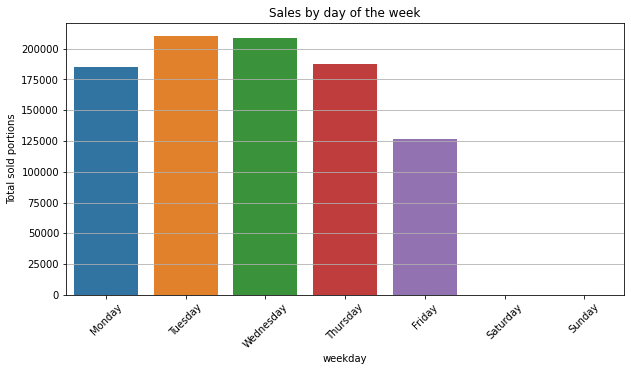

In [182]:
verkauf_df_enriched['weekday'] = pd.to_datetime(verkauf_df_enriched['date']).dt.day_name()

weekday_sales = verkauf_df_enriched.groupby('weekday')['sold_amount'].sum().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 5))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title('Sales by day of the week')
plt.ylabel('Total sold portions')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()
